# Análise de Comunicação — Inferência LLM Distribuída

Este notebook analisa a hipótese central do trabalho:
**o gargalo de escalabilidade no PCAD é a largura de banda da rede de interconexão**,
que limita o Tensor Parallel (TP) mas afeta menos o Pipeline Parallel (PP).

**Entrada:** `data_processed/comm_comp.csv` (gerado por `scripts/analyze_traces.py --data data/final`)  
**Saída:** figuras em `figures/communication_analysis/`

### Pré-requisito
Rodar dentro do ambiente `.#default` (que tem `nsys`):
```bash
nix develop .#default
python scripts/analyze_traces.py --data data/final
```
Depois retornar para `.#tools` para rodar este notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

matplotlib.rcParams.update({'figure.dpi': 150, 'font.size': 11})

BASE_DIR = Path('../data_processed')
FIG_DIR  = Path('../figures/communication_analysis')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Parâmetro principal da análise de banda
TARGET_PCT    = 20    # % máximo de comunicação considerado 'compute-bound'
# Banda nominal do PCAD: Ethernet 10 GbE. O iperf3 TCP single-flow mede ~0.94 Gbps
# (teto de um stream TCP), enquanto o NCCL satura a interface a 95-97% em TP
# (ver ifutil_peak). Usamos o valor medido quando disponível; o fallback abaixo
# é a banda nominal do enlace (10 GbE).
ASSUMED_BW_GBPS = 10

STRATEGY_COLORS = {'none': '#7f7f7f', 'TP': '#d62728', 'PP': '#1f77b4'}
WORKLOAD_LS     = {'short': '--', 'long': '-'}
NODE_MARKER     = {'poti': 'o', 'tupi': 's'}

def strategy_label(s):
    return {'none': 'Single GPU', 'TP': 'TP (AllReduce)', 'PP': 'PP (SendRecv)'}.get(s, s)

## 1. Carregamento dos dados

In [2]:
comm_csv = BASE_DIR / 'comm_comp.csv'
if not comm_csv.exists():
    raise FileNotFoundError(
        f"{comm_csv} não encontrado.\n"
        "Rode primeiro (dentro do shell com nsys):\n"
        "  python scripts/analyze_traces.py --data data/final"
    )

cc = pd.read_csv(comm_csv)

# Compatibilidade: garante comp_pct_head mesmo em CSVs mais antigos
if 'comp_pct_head' not in cc.columns:
    cc['comp_pct_head'] = 100 - cc['comm_pct_head']

cc['comm_pct'] = cc['comm_pct_head']
cc['comp_pct'] = cc['comp_pct_head']
cc['config'] = cc.apply(
    lambda r: f"N{r['n_gpus']} {r['strategy'].upper()} {r['workload'].capitalize()}", axis=1
)

_order = {'none': 0, 'TP': 1, 'PP': 2}
cc['_sort'] = cc['strategy'].map(_order)
cc = cc.sort_values(['_sort', 'n_gpus', 'workload']).drop(columns='_sort').reset_index(drop=True)

print(f"Experimentos carregados: {len(cc)}")
display(cc[['run', 'n_gpus', 'strategy', 'workload', 'comm_pct',
            'dominant_collective', 'itl_ms', 'throughput_req_s', 'iperf3_gbps']])

Experimentos carregados: 14


,run,n_gpus,strategy,workload,comm_pct,dominant_collective,itl_ms,throughput_req_s,iperf3_gbps
0,N1_tupi_none_long_r1_798983,1,none,long,0.000000,NaN,17.491661,0.111244,NaN
1,N1_tupi_none_short_r1_790477,1,none,short,0.000000,NaN,18.332669,0.423106,NaN
2,N2_poti_TP_long_r1_790072,2,TP,long,58.482780,AllReduce,31.145225,0.222012,0.941274
3,N2_tupi_TP_long_r1_798983,2,TP,long,96.730594,AllReduce,23.149981,0.064990,0.941265
4,N2_poti_TP_short_r1_790073,2,TP,short,55.195466,AllReduce,30.142186,0.228258,0.941279
5,N2_tupi_TP_short_r1_796872,2,TP,short,96.944276,AllReduce,22.692790,0.292158,0.941269
6,N4_poti_TP_long_r1_790077,4,TP,long,81.461449,AllReduce,39.160995,0.173517,0.941223
7,N4_poti_TP_short_r1_790075,4,TP,short,81.598498,AllReduce,39.051290,0.173902,0.941231
8,N2_poti_PP_long_r1_790071,2,PP,long,0.237007,SendRecv,35.047521,0.220769,0.941311
9,N2_tupi_PP_long_r1_796872,2,PP,long,23.807623,SendRecv,19.707039,0.097908,0.941282


## 2. Decomposição comunicação / computação

Cada barra mostra quanto do tempo total de GPU (rank 0) foi gasto em kernels NCCL
(comunicação) vs. demais kernels CUDA (computação). A linha tracejada em 50% separa
regimes **comm-bound** (acima) de **compute-bound** (abaixo).

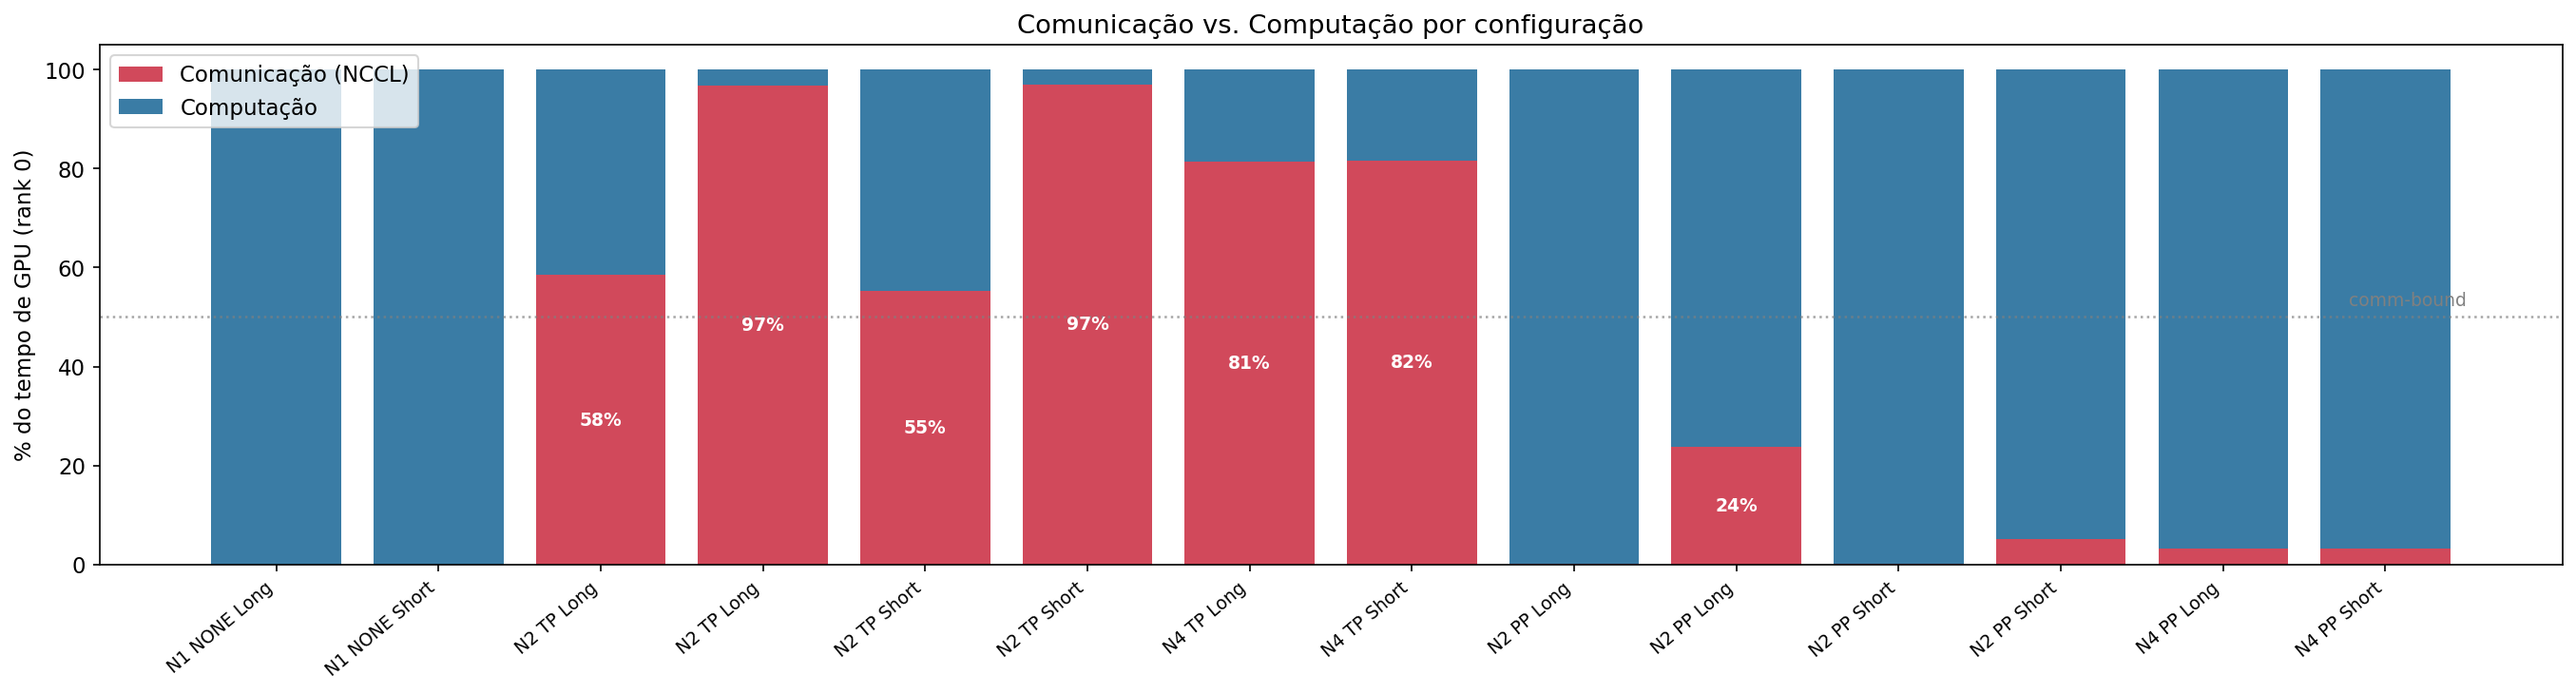

In [3]:
fig, ax = plt.subplots(figsize=(max(8, len(cc) * 1.3), 5))

x      = np.arange(len(cc))
labels = cc['config'].tolist()

ax.bar(x, cc['comm_pct'], color='#d1495b', label='Comunicação (NCCL)')
ax.bar(x, cc['comp_pct'], bottom=cc['comm_pct'], color='#3a7ca5', label='Computação')

for i, row in cc.iterrows():
    if row['comm_pct'] >= 8:
        ax.text(x[i], row['comm_pct'] / 2, f"{row['comm_pct']:.0f}%",
                ha='center', va='center', color='white', fontsize=9, fontweight='bold')

ax.axhline(50, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(len(cc) - 0.5, 51.5, 'comm-bound', ha='right', va='bottom', color='gray', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('% do tempo de GPU (rank 0)')
ax.set_ylim(0, 105)
ax.set_title('Comunicação vs. Computação por configuração')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / 'comm-comp-breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

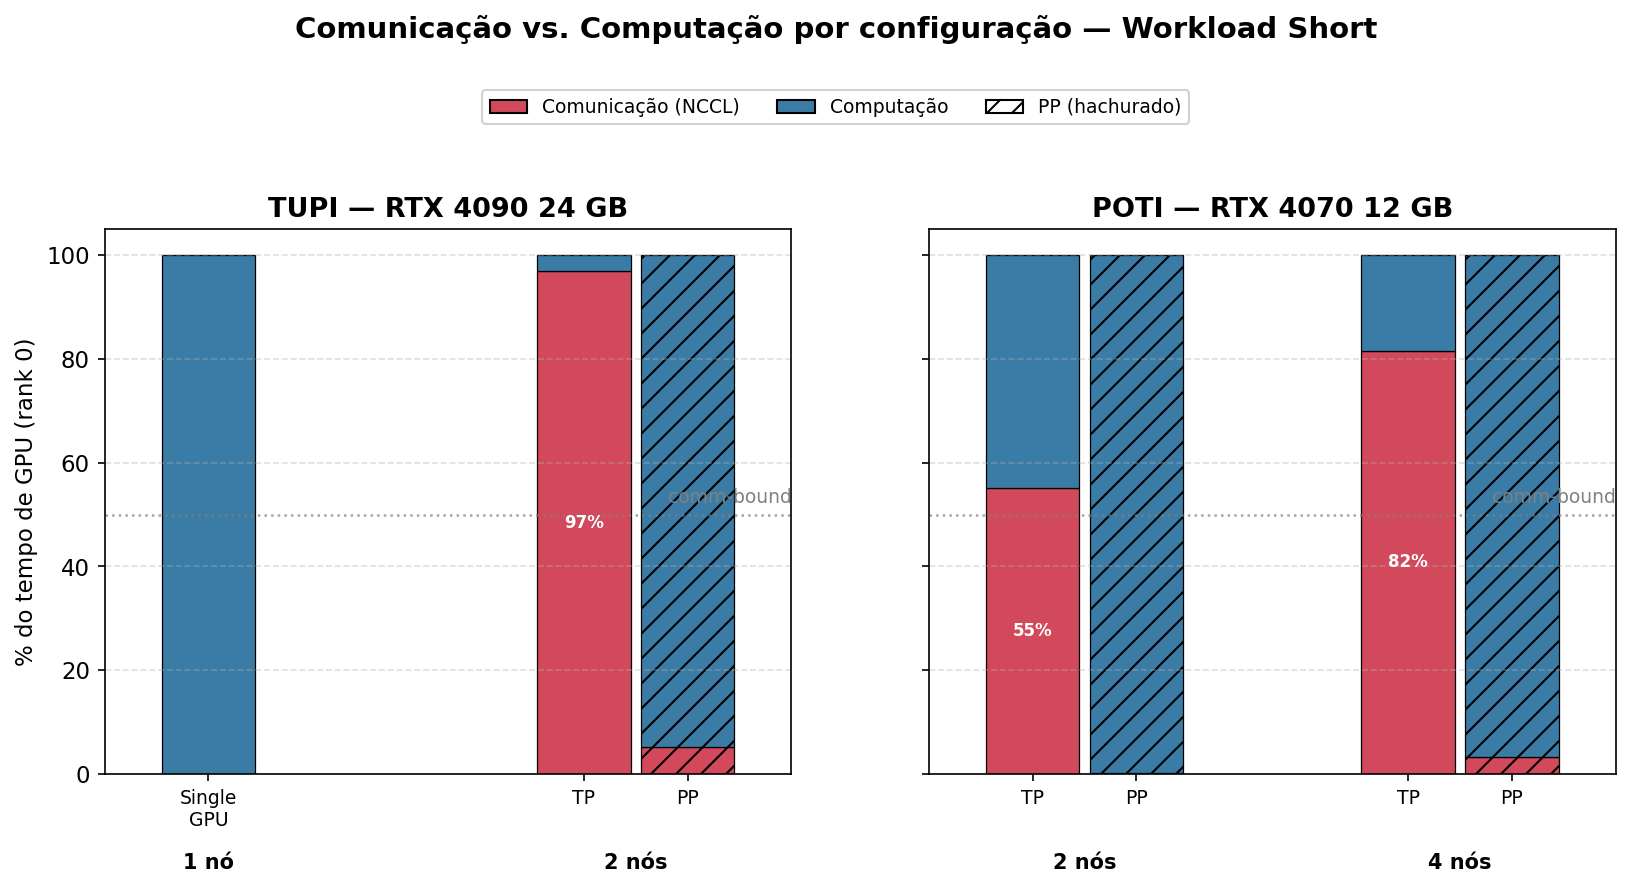

In [4]:
cc_short = cc[cc['workload'] == 'short'].reset_index(drop=True)
NODE_TITLES     = {'tupi': 'TUPI — RTX 4090 24 GB', 'poti': 'POTI — RTX 4070 12 GB'}
STRAT_ORDER     = ['none', 'TP', 'PP']
STRAT_XLABEL    = {'none': 'Single\nGPU', 'TP': 'TP', 'PP': 'PP'}
STRAT_HATCH     = {'none': '', 'TP': '', 'PP': '//'}
nodes_present   = [n for n in ['tupi', 'poti'] if n in cc_short['node'].values]

fig, axes = plt.subplots(1, len(nodes_present), figsize=(6.5 * len(nodes_present), 5.5), sharey=True)
if len(nodes_present) == 1:
    axes = [axes]

bar_w     = 0.34
group_gap = 0.55

for idx, node in enumerate(nodes_present):
    ax = axes[idx]
    sub = cc_short[cc_short['node'] == node]
    n_gpus_vals = sorted(sub['n_gpus'].unique())

    xticks, xticklabels, group_centers = [], [], []

    for gi, n in enumerate(n_gpus_vals):
        grp = sub[sub['n_gpus'] == n]
        strats = [s for s in STRAT_ORDER if s in set(grp['strategy'])]
        base_x = gi * (len(strats) * bar_w + group_gap)
        bar_centers = base_x + np.arange(len(strats)) * bar_w
        group_centers.append(bar_centers.mean())

        for xpos, strat in zip(bar_centers, strats):
            row = grp[grp['strategy'] == strat].iloc[0]
            hatch = STRAT_HATCH.get(strat, '')
            ax.bar(xpos, row['comm_pct'], width=bar_w * 0.9, color='#d1495b',
                   edgecolor='black', linewidth=0.6, hatch=hatch)
            ax.bar(xpos, row['comp_pct'], width=bar_w * 0.9, bottom=row['comm_pct'],
                   color='#3a7ca5', edgecolor='black', linewidth=0.6, hatch=hatch)
            if row['comm_pct'] >= 8:
                ax.text(xpos, row['comm_pct'] / 2, f"{row['comm_pct']:.0f}%",
                        ha='center', va='center', color='white', fontsize=8, fontweight='bold')
            xticks.append(xpos)
            xticklabels.append(STRAT_XLABEL.get(strat, strat))

    ax.axhline(50, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(xticks[-1] + bar_w, 51.5, 'comm-bound', ha='right', va='bottom', color='gray', fontsize=9)

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=9)
    for gc, n in zip(group_centers, n_gpus_vals):
        ax.annotate(f'{n} nó' if n == 1 else f'{n} nós',
                    xy=(gc, 0), xycoords=('data', 'axes fraction'),
                    xytext=(0, -38), textcoords='offset points',
                    ha='center', va='top', fontsize=10, fontweight='bold',
                    annotation_clip=False)

    ax.set_xlim(min(xticks) - bar_w, max(xticks) + bar_w)
    ax.set_ylabel('% do tempo de GPU (rank 0)' if idx == 0 else '')
    ax.set_ylim(0, 105)
    ax.set_title(NODE_TITLES.get(node, node.upper()), fontsize=13, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

handles = [
    mpatches.Patch(facecolor='#d1495b', edgecolor='black', label='Comunicação (NCCL)'),
    mpatches.Patch(facecolor='#3a7ca5', edgecolor='black', label='Computação'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='//', label='PP (hachurado)'),
]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.06), fontsize=9, framealpha=0.9)

fig.suptitle('Comunicação vs. Computação por configuração — Workload Short', fontsize=14, fontweight='bold', y=1.14)
fig.subplots_adjust(bottom=0.22)
fig.savefig(FIG_DIR / 'comm-comp-breakdown-short.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. TP vs PP: padrões de comunicação

- **TP (Tensor Parallel)** insere um *AllReduce* a cada camada do transformer durante
  prefill **e** decode — comunicação **fina e frequente**, proporcional a
  `hidden_size × seq_len × n_layers`.
- **PP (Pipeline Parallel)** transfere ativações nas fronteiras de estágio — comunicação
  **grossa e infrequente**, limitada ao número de cortes no modelo.

Esperamos que TP seja sistematicamente mais comm-bound que PP, e que a fração cresça
mais rápido com N no TP do que no PP.

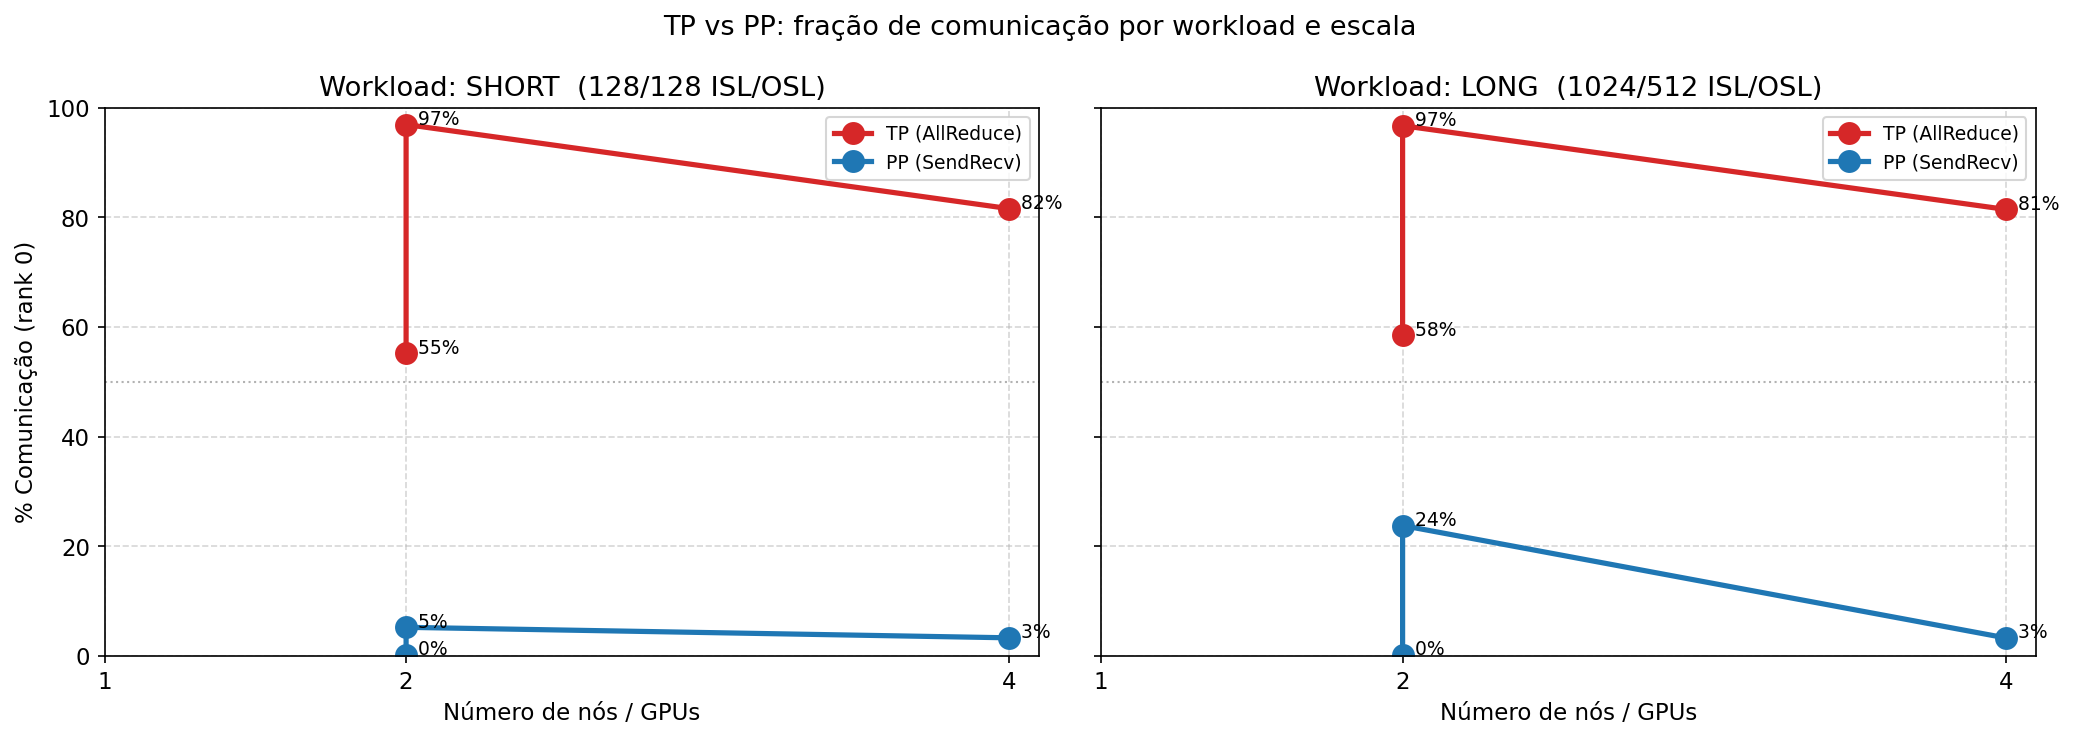

In [5]:
workloads = [w for w in ['short', 'long'] if w in cc['workload'].values]
fig, axes = plt.subplots(1, len(workloads), figsize=(7 * len(workloads), 5), sharey=True)
if len(workloads) == 1:
    axes = [axes]

for idx, wl in enumerate(workloads):
    ax = axes[idx]
    for strategy in ['TP', 'PP']:
        sub = cc[(cc['strategy'] == strategy) & (cc['workload'] == wl)].sort_values('n_gpus')
        if sub.empty:
            continue
        ax.plot(sub['n_gpus'], sub['comm_pct'],
                marker='o', linewidth=2.5, markersize=10,
                color=STRATEGY_COLORS[strategy],
                label=strategy_label(strategy))
        for _, row in sub.iterrows():
            ax.annotate(f"  {row['comm_pct']:.0f}%",
                        (row['n_gpus'], row['comm_pct']), fontsize=9)

    isl_osl = '128/128' if wl == 'short' else '1024/512'
    ax.set_title(f"Workload: {wl.upper()}  ({isl_osl} ISL/OSL)")
    ax.set_xlabel('Número de nós / GPUs')
    ax.set_ylabel('% Comunicação (rank 0)' if idx == 0 else '')
    ax.set_ylim(0, 100)
    all_n = sorted(cc['n_gpus'].unique())
    ax.set_xticks(all_n)
    ax.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.legend(fontsize=9)
    ax.grid(linestyle='--', alpha=0.5)

fig.suptitle('TP vs PP: fração de comunicação por workload e escala', fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / 'tp-vs-pp-comm-fraction.png', dpi=150, bbox_inches='tight')
plt.show()

## 3b. Saturação da interface de rede (evidência direta)

O `%ifutil` (sar) mede a utilização da interface `192.168.*` em cada nó. Se a comunicação
é o gargalo, o tráfego do *AllReduce* (TP) deve saturar o enlace, enquanto o *SendRecv*
(PP) o usa pouco. A correlação de Pearson entre `comm_pct` e `ifutil_peak` é a evidência
**mais direta** da tese.

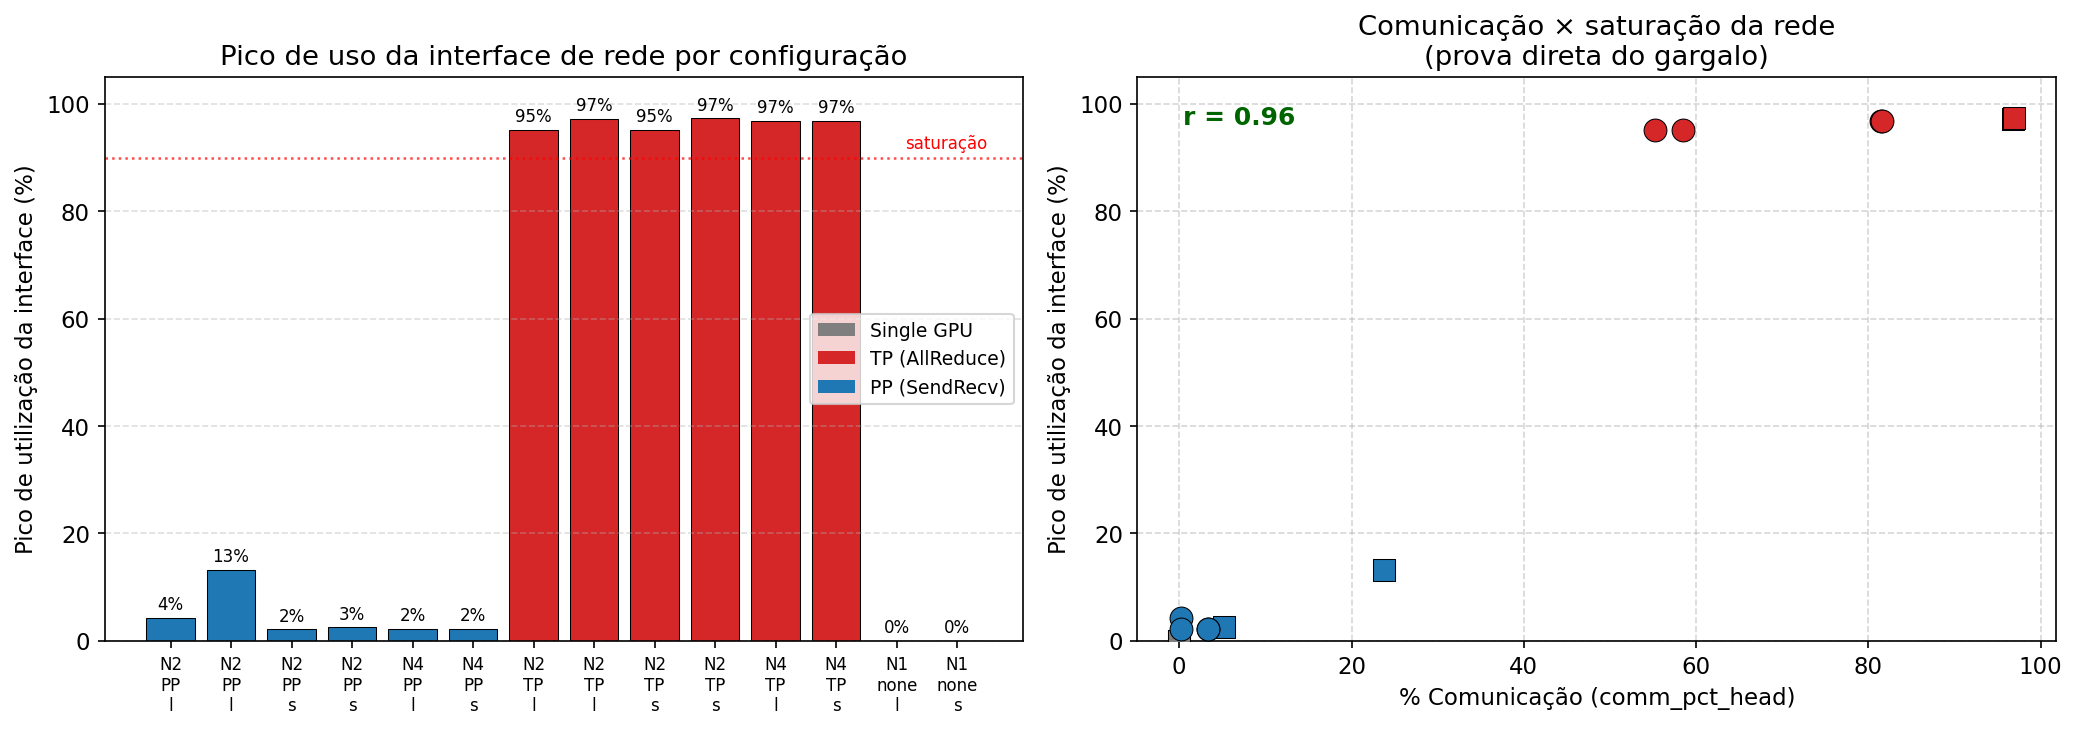

Correlação Pearson r(comm_pct, ifutil_peak) = 0.959 — rede saturada pelo AllReduce do TP.
TP: pico ifutil = 95–97%
PP: pico ifutil = 2–13%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- esquerda: ifutil_peak por config ---
ax = axes[0]
order = cc.sort_values(['strategy', 'n_gpus', 'workload']).reset_index(drop=True)
x = np.arange(len(order))
colors = [STRATEGY_COLORS[s] for s in order['strategy']]
ax.bar(x, order['ifutil_peak'], color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(order['ifutil_peak']):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha='center', fontsize=8)
labels = [f"N{r['n_gpus']}\n{r['strategy']}\n{r['workload'][:1]}" for _, r in order.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Pico de utilização da interface (%)')
ax.set_ylim(0, 105)
ax.axhline(90, color='red', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(len(order)-0.5, 91, 'saturação', ha='right', va='bottom', color='red', fontsize=8)
ax.set_title('Pico de uso da interface de rede por configuração')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# legenda manual
handles = [mpatches.Patch(facecolor=STRATEGY_COLORS[s], label=strategy_label(s))
           for s in ['none', 'TP', 'PP']]
ax.legend(handles=handles, fontsize=9, loc='center right')

# --- direita: scatter comm% x ifutil ---
ax = axes[1]
for _, row in cc.iterrows():
    ax.scatter(row['comm_pct'], row['ifutil_peak'],
               c=STRATEGY_COLORS.get(row['strategy'], 'gray'),
               marker=NODE_MARKER.get(row['node'], 'o'),
               s=120, edgecolors='black', linewidths=0.5, zorder=5)
valid = cc[['comm_pct', 'ifutil_peak']].dropna()
if len(valid) >= 3:
    r = valid.corr().iloc[0, 1]
    ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
            fontsize=12, va='top', color='darkgreen', fontweight='bold')

ax.set_xlabel('% Comunicação (comm_pct_head)')
ax.set_ylabel('Pico de utilização da interface (%)')
ax.set_ylim(0, 105)
ax.set_title('Comunicação × saturação da rede\n(prova direta do gargalo)')
ax.grid(linestyle='--', alpha=0.5)

fig.tight_layout()
fig.savefig(FIG_DIR / 'network-saturation.png', dpi=150, bbox_inches='tight')
plt.show()

if len(valid) >= 3:
    print(f"Correlação Pearson r(comm_pct, ifutil_peak) = {r:.3f} — rede saturada pelo AllReduce do TP.")
    print(f"TP: pico ifutil = {cc[cc['strategy']=='TP']['ifutil_peak'].min():.0f}–{cc[cc['strategy']=='TP']['ifutil_peak'].max():.0f}%")
    print(f"PP: pico ifutil = {cc[cc['strategy']=='PP']['ifutil_peak'].min():.0f}–{cc[cc['strategy']=='PP']['ifutil_peak'].max():.0f}%")

## 4. Escalabilidade da fração de comunicação com N

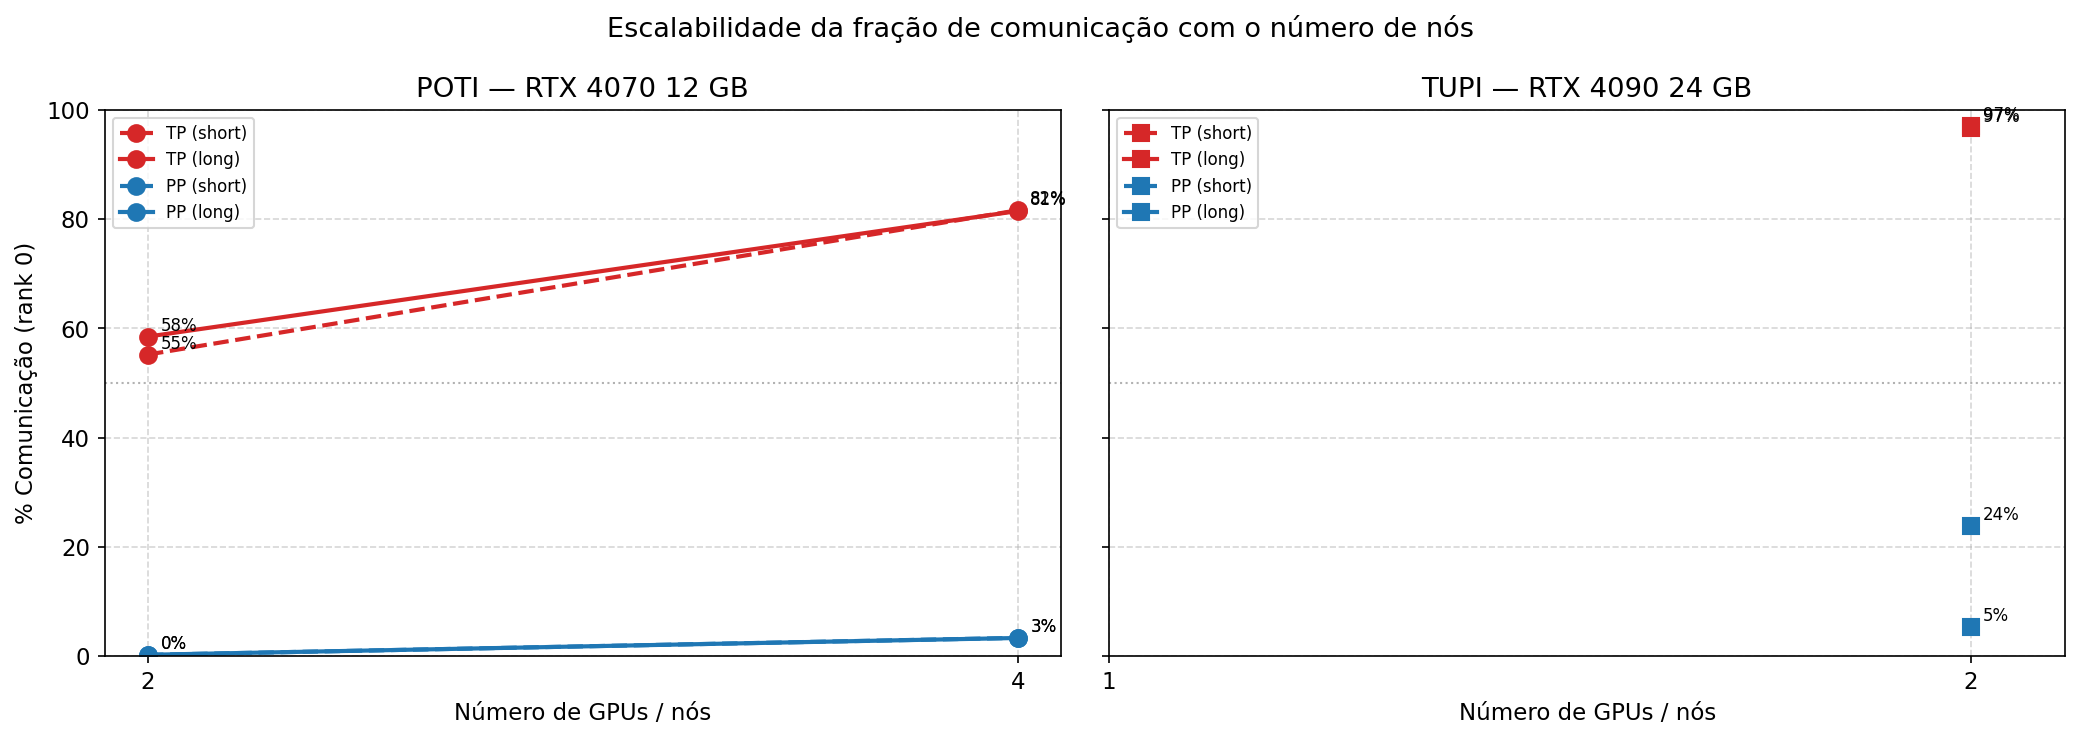

In [7]:
nodes_with_data = [n for n in ['poti', 'tupi'] if n in cc['node'].values]
fig, axes = plt.subplots(1, len(nodes_with_data),
                          figsize=(7 * len(nodes_with_data), 5), sharey=True)
if len(nodes_with_data) == 1:
    axes = [axes]

GPU_NAMES = {'poti': 'RTX 4070 12 GB', 'tupi': 'RTX 4090 24 GB'}

for idx, node in enumerate(nodes_with_data):
    ax = axes[idx]
    node_df = cc[(cc['node'] == node) & (cc['strategy'] != 'none')]

    for strategy in ['TP', 'PP']:
        for wl in ['short', 'long']:
            sub = node_df[(node_df['strategy'] == strategy) & (node_df['workload'] == wl)]\
                         .sort_values('n_gpus')
            if sub.empty:
                continue
            ax.plot(sub['n_gpus'], sub['comm_pct'],
                    marker=NODE_MARKER.get(node, 'o'),
                    color=STRATEGY_COLORS[strategy],
                    linestyle=WORKLOAD_LS.get(wl, '-'),
                    linewidth=2, markersize=8,
                    label=f"{strategy} ({wl})")
            for _, row in sub.iterrows():
                ax.annotate(f"{row['comm_pct']:.0f}%",
                            (row['n_gpus'], row['comm_pct']),
                            textcoords='offset points', xytext=(6, 3), fontsize=8)

    ax.set_title(f"{node.upper()} — {GPU_NAMES.get(node, '')}")
    ax.set_xlabel('Número de GPUs / nós')
    ax.set_ylabel('% Comunicação (rank 0)' if idx == 0 else '')
    all_n = sorted(cc[cc['node'] == node]['n_gpus'].unique())
    ax.set_xticks(all_n)
    ax.set_ylim(0, 100)
    ax.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.legend(fontsize=8)
    ax.grid(linestyle='--', alpha=0.5)

fig.suptitle('Escalabilidade da fração de comunicação com o número de nós', fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / 'comm-fraction-scaling.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlação: fração de comunicação × métricas de performance

Se a hipótese de gargalo de comunicação estiver correta, esperamos:
- Correlação **positiva** entre `comm_pct` e `itl_ms`, `ttft_ms`, `latency_ms`
  (mais comunicação → maior latência).
- Correlação **negativa** entre `comm_pct` e `throughput_req_s`
  (mais comunicação → menor throughput).

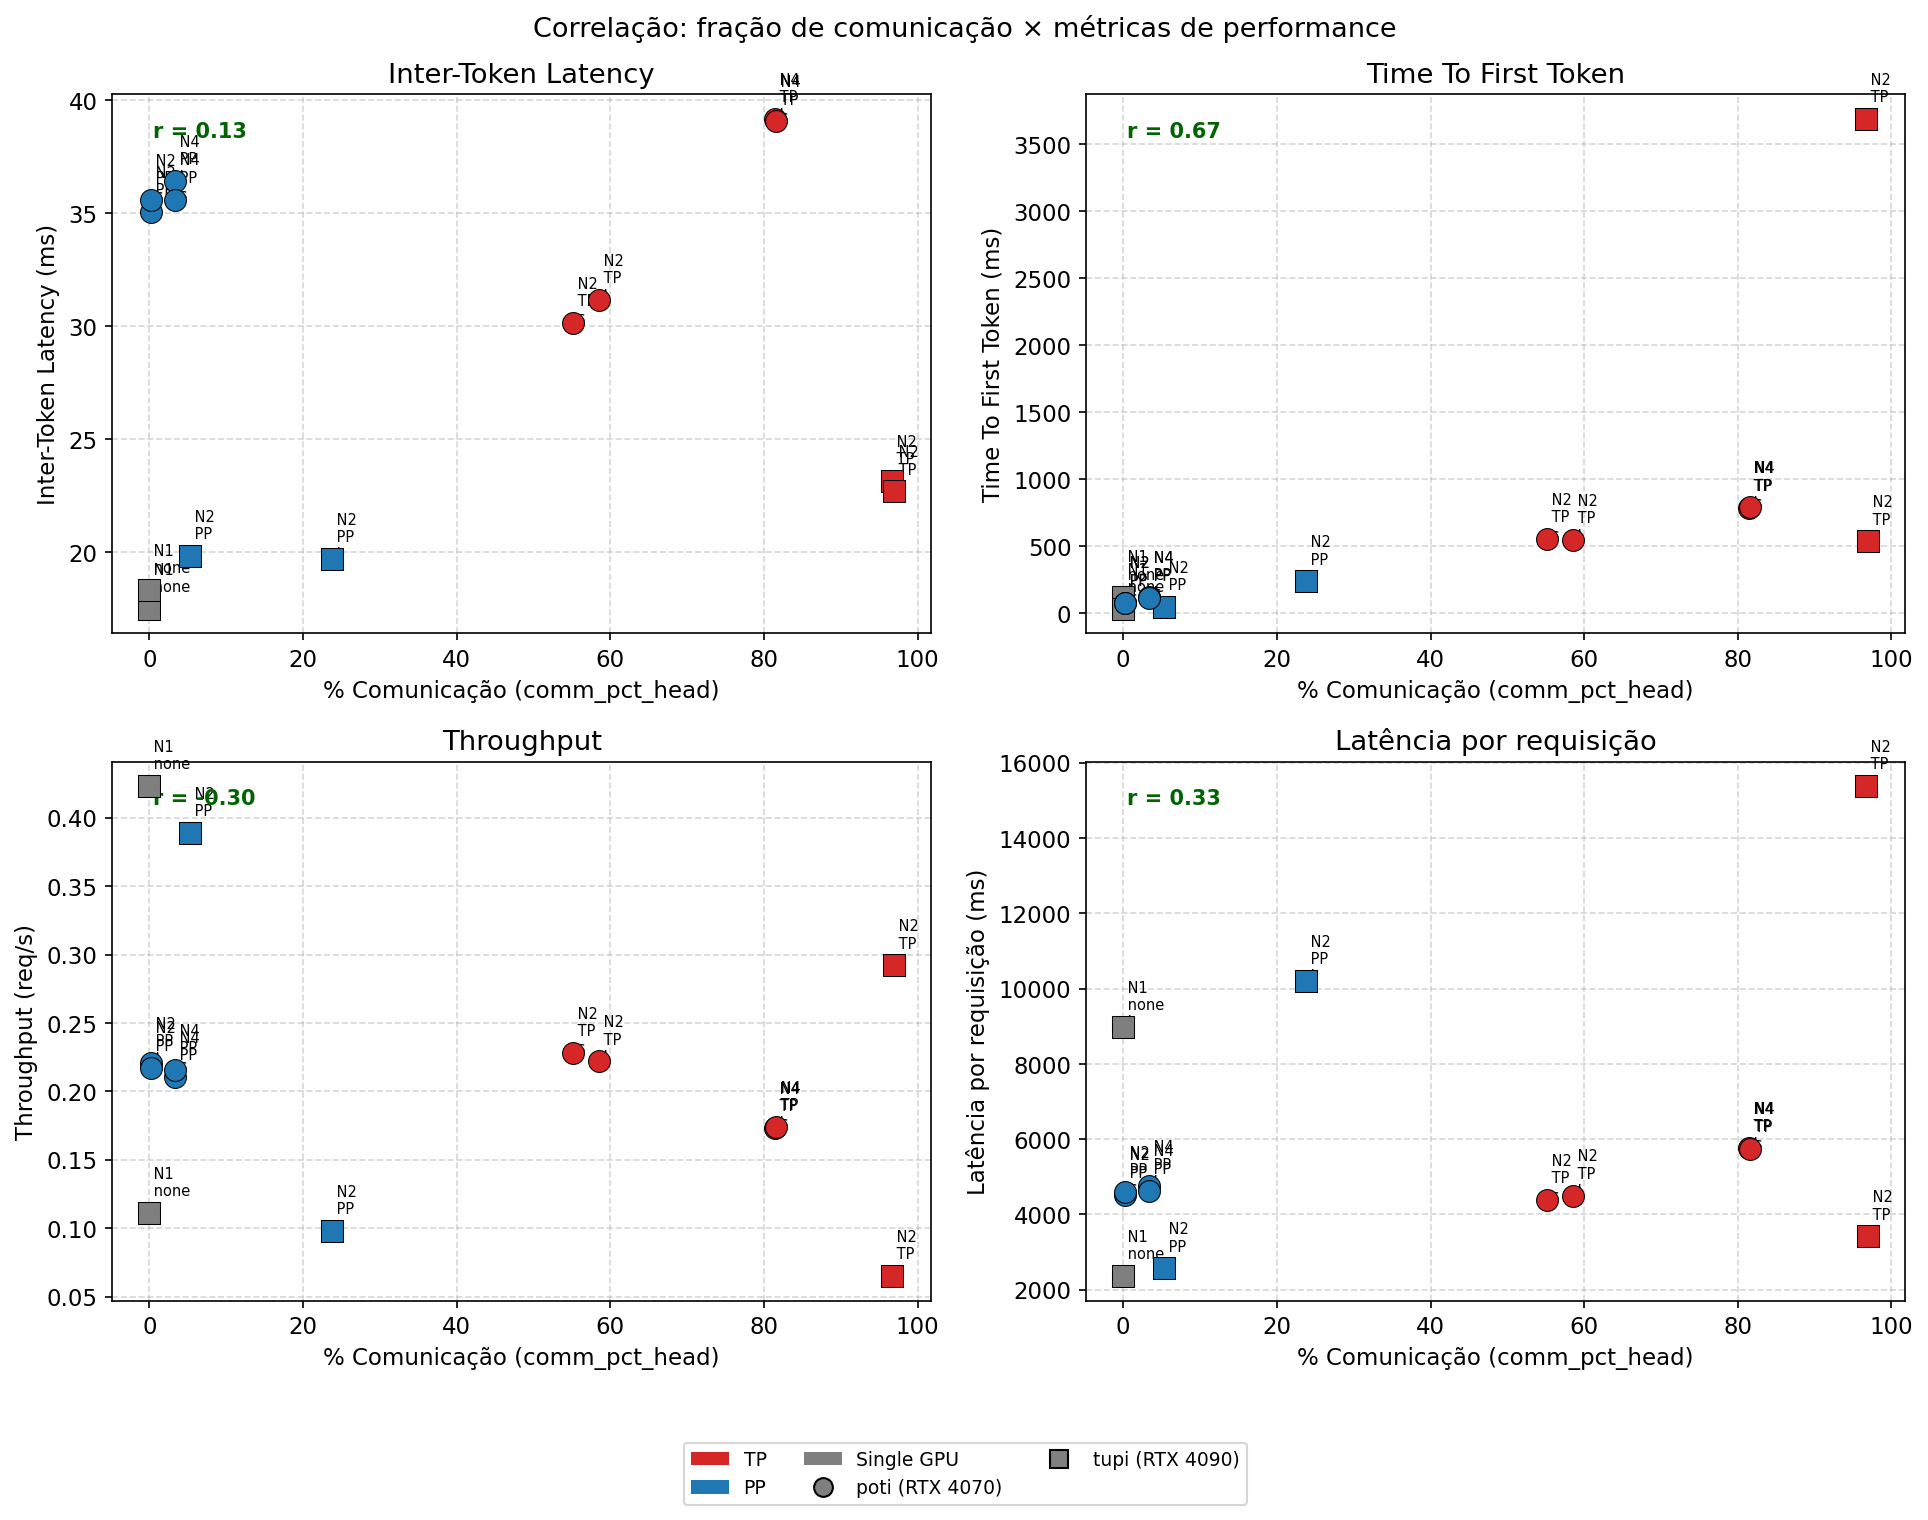

In [8]:
METRICS = [
    ('itl_ms',           'Inter-Token Latency (ms)',    True),
    ('ttft_ms',          'Time To First Token (ms)',     True),
    ('throughput_req_s', 'Throughput (req/s)',           False),
    ('latency_ms',       'Latência por requisição (ms)', True),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (col, ylabel, higher_is_worse) in zip(axes, METRICS):
    sub = cc[cc[col].notna()].copy()
    for _, row in sub.iterrows():
        c = STRATEGY_COLORS.get(row['strategy'], 'gray')
        m = NODE_MARKER.get(row['node'], 'o')
        ax.scatter(row['comm_pct'], row[col], c=c, marker=m,
                   s=110, edgecolors='black', linewidths=0.5, zorder=5)
        ax.annotate(
            f" N{int(row['n_gpus'])}\n {row['strategy']}\n {row['workload'][:1]}",
            (row['comm_pct'], row[col]), fontsize=7
        )

    if len(sub) >= 3:
        r = sub[['comm_pct', col]].dropna().corr().iloc[0, 1]
        expected_sign = r > 0 if higher_is_worse else r < 0
        color = 'darkgreen' if expected_sign else 'gray'
        ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
                fontsize=10, va='top', color=color, fontweight='bold')

    ax.set_xlabel('% Comunicação (comm_pct_head)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split('(')[0].strip())
    ax.grid(linestyle='--', alpha=0.5)

legend_elements = [
    mpatches.Patch(facecolor=STRATEGY_COLORS['TP'],   label='TP'),
    mpatches.Patch(facecolor=STRATEGY_COLORS['PP'],   label='PP'),
    mpatches.Patch(facecolor=STRATEGY_COLORS['none'], label='Single GPU'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='black', label='poti (RTX 4070)', markersize=9),
    plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='gray',
               markeredgecolor='black', label='tupi (RTX 4090)', markersize=9),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Correlação: fração de comunicação × métricas de performance', fontsize=13)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(FIG_DIR / 'comm-perf-correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Estimativa de banda de rede ideal para o PCAD

### Modelo

Assumindo que dobrar a banda de rede reduz o tempo de comunicação pela metade
(modelo linear de throughput de rede), o speedup de banda necessário para reduzir
a fração de comunicação de `comm_pct%` para `target_pct%` é:

$$k = \frac{\text{comm\_pct} \times (100 - \text{target\_pct})}{\text{comp\_pct} \times \text{target\_pct}}$$

Se a banda atual for `B` Gbps, a banda necessária é `k × B` Gbps.

### Referência de banda atual
Se `iperf3` foi coletado nos experimentos, o CSV já tem `iperf3_gbps` medido entre os nós.
Caso contrário, usa-se `ASSUMED_BW_GBPS` (configurado na célula de setup).

### Limitação do modelo
O modelo assume que toda a comunicação é limitada pela banda da rede (o que é válido
para Ethernet sem NVLink). Em redes com alta latência relativa à banda (latency-bound
ao invés de bandwidth-bound), o speedup real pode ser menor. Para o Qwen2.5-7B-Instruct com
decode de 1 token, cada AllReduce transfere poucos KB por camada — operações pequenas que
são mais latency-bound; portanto o `k` calculado é um **limite inferior conservador**
(a banda real necessária pode ser maior).

In [9]:
tp_df = cc[cc['strategy'] == 'TP'].copy()

# Calcula speedup de banda necessário
tp_df['speedup_needed'] = (
    tp_df['comm_pct'] * (100 - TARGET_PCT) / (tp_df['comp_pct'] * TARGET_PCT)
)

# Referência de banda
if tp_df['iperf3_gbps'].notna().any():
    tp_df['ref_bw'] = tp_df['iperf3_gbps'].fillna(ASSUMED_BW_GBPS)
    bw_source = "iperf3 medido"
else:
    tp_df['ref_bw'] = ASSUMED_BW_GBPS
    bw_source = f"estimado {ASSUMED_BW_GBPS} Gbps (10GbE — referência típica PCAD)"

tp_df['ideal_gbps'] = tp_df['speedup_needed'] * tp_df['ref_bw']

print(f"Banda de referência: {bw_source}")
print(f"Alvo de comunicação: ≤{TARGET_PCT}% (abaixo disso = compute-bound)")
print()
print(tp_df[['run', 'n_gpus', 'workload', 'comm_pct', 'ref_bw',
             'speedup_needed', 'ideal_gbps']].to_string(index=False, float_format='{:.1f}'.format))

Banda de referência: iperf3 medido
Alvo de comunicação: ≤20% (abaixo disso = compute-bound)

                       run  n_gpus workload  comm_pct  ref_bw  speedup_needed  ideal_gbps
 N2_poti_TP_long_r1_790072       2     long      58.5     0.9             5.6         5.3
 N2_tupi_TP_long_r1_798983       2     long      96.7     0.9           118.3       111.4
N2_poti_TP_short_r1_790073       2    short      55.2     0.9             4.9         4.6
N2_tupi_TP_short_r1_796872       2    short      96.9     0.9           126.9       119.4
 N4_poti_TP_long_r1_790077       4     long      81.5     0.9            17.6        16.5
N4_poti_TP_short_r1_790075       4    short      81.6     0.9            17.7        16.7


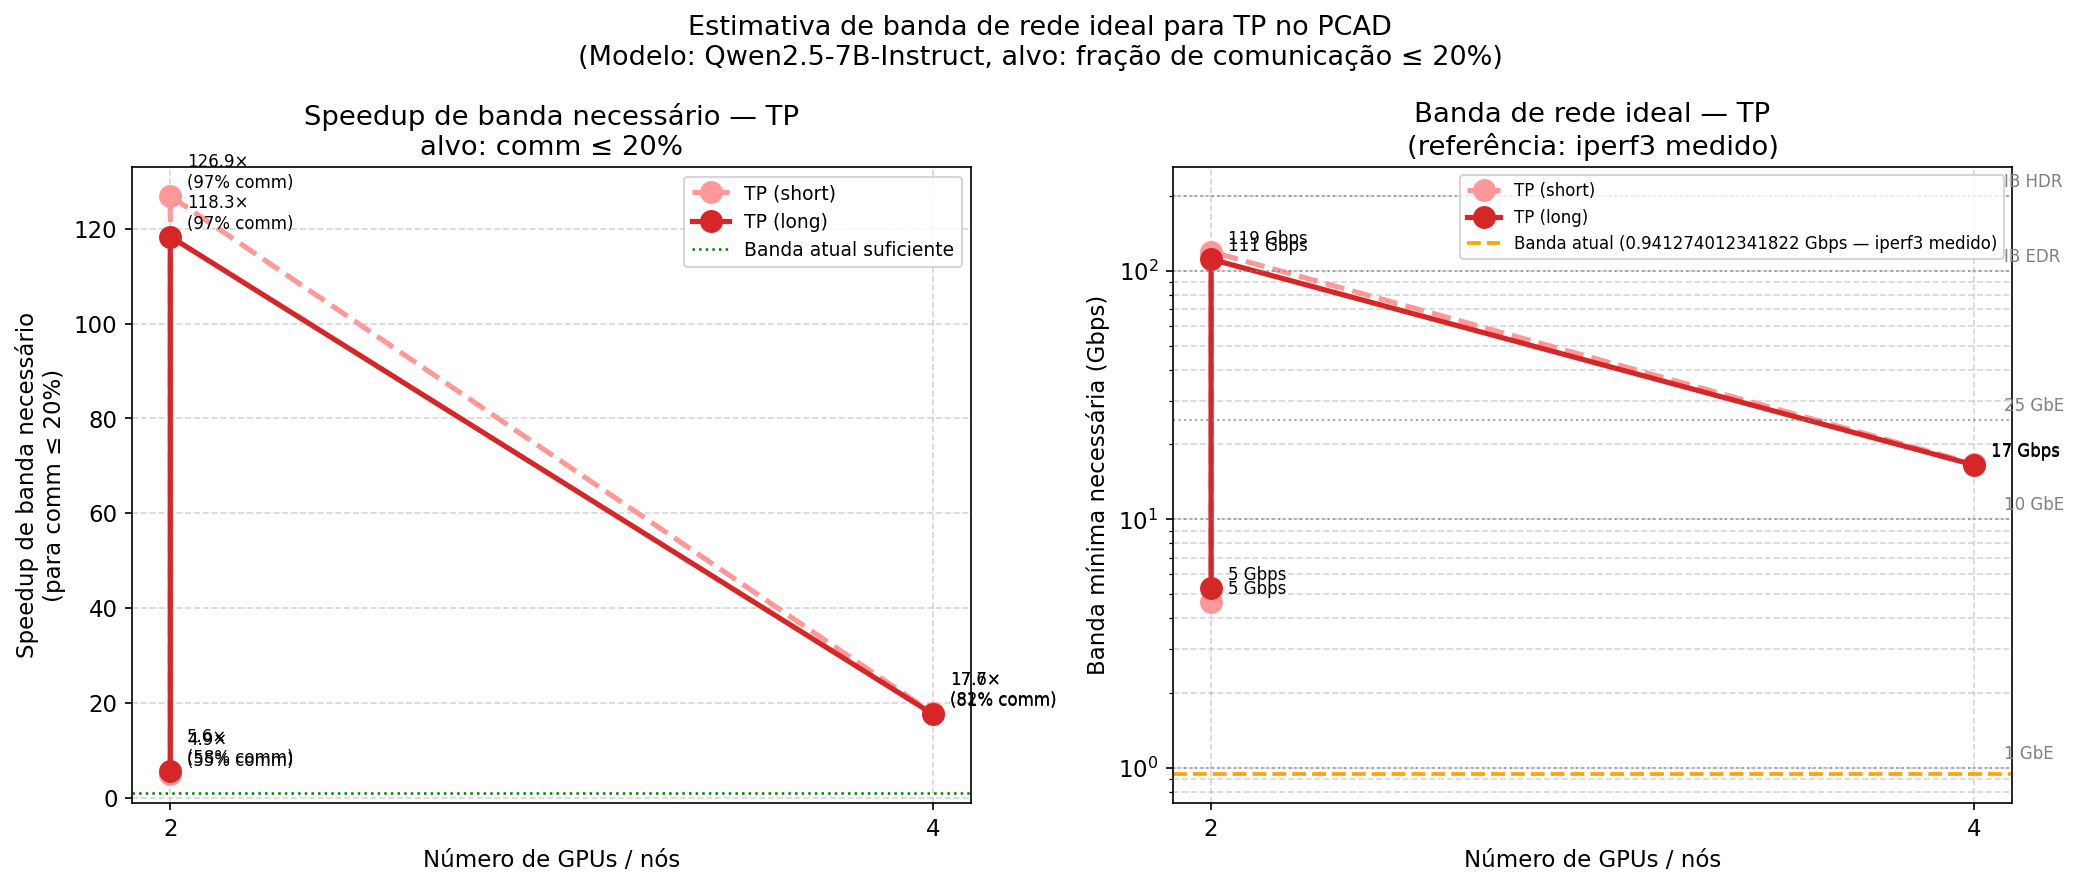

In [10]:
BANDWIDTH_REFS = [
    ('1 GbE',       1),
    ('10 GbE',     10),
    ('25 GbE',     25),
    ('IB EDR',    100),
    ('IB HDR',    200),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- subplot esquerdo: speedup adimensional ---
ax = axes[0]
for wl in ['short', 'long']:
    sub = tp_df[tp_df['workload'] == wl].sort_values('n_gpus')
    if sub.empty:
        continue
    color = '#d62728' if wl == 'long' else '#ff9999'
    ax.plot(sub['n_gpus'], sub['speedup_needed'],
            marker='o', linewidth=2.5, markersize=10,
            linestyle=WORKLOAD_LS.get(wl, '-'), color=color,
            label=f"TP ({wl})")
    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['speedup_needed']:.1f}×\n({row['comm_pct']:.0f}% comm)",
            (row['n_gpus'], row['speedup_needed']),
            textcoords='offset points', xytext=(8, 4), fontsize=8
        )

ax.axhline(1, color='green', linestyle=':', linewidth=1.2, label='Banda atual suficiente')
ax.set_xlabel('Número de GPUs / nós')
ax.set_ylabel(f'Speedup de banda necessário\n(para comm ≤ {TARGET_PCT}%)')
ax.set_title(f'Speedup de banda necessário — TP\nalvo: comm ≤ {TARGET_PCT}%')
all_n = sorted(tp_df['n_gpus'].unique())
ax.set_xticks(all_n)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.5)

# --- subplot direito: banda absoluta ---
ax = axes[1]
for wl in ['short', 'long']:
    sub = tp_df[tp_df['workload'] == wl].sort_values('n_gpus')
    if sub.empty:
        continue
    color = '#d62728' if wl == 'long' else '#ff9999'
    ax.plot(sub['n_gpus'], sub['ideal_gbps'],
            marker='o', linewidth=2.5, markersize=10,
            linestyle=WORKLOAD_LS.get(wl, '-'), color=color,
            label=f"TP ({wl})")
    for _, row in sub.iterrows():
        ax.annotate(f"{row['ideal_gbps']:.0f} Gbps",
                    (row['n_gpus'], row['ideal_gbps']),
                    textcoords='offset points', xytext=(8, 4), fontsize=8)

for label, bw in BANDWIDTH_REFS:
    ax.axhline(bw, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax.text(all_n[-1] + 0.08, bw * 1.05, label, fontsize=8, va='bottom', color='gray')

ref_bw = tp_df['ref_bw'].iloc[0] if not tp_df.empty else ASSUMED_BW_GBPS
ax.axhline(ref_bw, color='orange', linestyle='--', linewidth=1.8,
           label=f'Banda atual ({ref_bw} Gbps — {bw_source})')

ax.set_xlabel('Número de GPUs / nós')
ax.set_ylabel('Banda mínima necessária (Gbps)')
ax.set_title(f'Banda de rede ideal — TP\n(referência: {bw_source})')
ax.set_xticks(all_n)
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(linestyle='--', alpha=0.5, which='both')

fig.suptitle(
    f'Estimativa de banda de rede ideal para TP no PCAD\n'
    f'(Modelo: Qwen2.5-7B-Instruct, alvo: fração de comunicação ≤ {TARGET_PCT}%)',
    fontsize=13
)
fig.tight_layout()
fig.savefig(FIG_DIR / 'bandwidth-estimation-tp.png', dpi=150, bbox_inches='tight')
plt.show()

### Projeção: como a comm% muda com diferentes bandas de rede?

A tabela abaixo mostra a fração de comunicação projetada para cada configuração
caso a banda de rede fosse multiplicada pelos fatores indicados (relativo à banda atual).

In [11]:
BANDWIDTHS_K = [1, 2, 5, 10, 25]

rows = []
for _, row in cc[cc['strategy'] != 'none'].iterrows():
    r = {
        'configuração': f"N{row['n_gpus']} {row['strategy']} {row['workload']}",
        'comm% atual':  f"{row['comm_pct']:.1f}%",
    }
    for k in BANDWIDTHS_K:
        new_comm = row['comm_pct'] / (row['comp_pct'] * k + row['comm_pct']) * 100
        r[f'{k}× banda'] = f"{new_comm:.1f}%"
    rows.append(r)

proj_df = pd.DataFrame(rows)
display(proj_df.to_html(index=False))
print(f"\nSe {TARGET_PCT}% é o alvo, células ≤{TARGET_PCT}% = compute-bound com aquela banda.")

'<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>configuração</th>\n      <th>comm% atual</th>\n      <th>1× banda</th>\n      <th>2× banda</th>\n      <th>5× banda</th>\n      <th>10× banda</th>\n      <th>25× banda</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>N2 TP long</td>\n      <td>58.5%</td>\n      <td>58.5%</td>\n      <td>41.3%</td>\n      <td>22.0%</td>\n      <td>12.3%</td>\n      <td>5.3%</td>\n    </tr>\n    <tr>\n      <td>N2 TP long</td>\n      <td>96.7%</td>\n      <td>96.7%</td>\n      <td>93.7%</td>\n      <td>85.5%</td>\n      <td>74.7%</td>\n      <td>54.2%</td>\n    </tr>\n    <tr>\n      <td>N2 TP short</td>\n      <td>55.2%</td>\n      <td>55.2%</td>\n      <td>38.1%</td>\n      <td>19.8%</td>\n      <td>11.0%</td>\n      <td>4.7%</td>\n    </tr>\n    <tr>\n      <td>N2 TP short</td>\n      <td>96.9%</td>\n      <td>96.9%</td>\n      <td>94.1%</td>\n      <td>86.4%</td>\n      <td>76.0%</td>\n      <t


Se 20% é o alvo, células ≤20% = compute-bound com aquela banda.


## 7. Resumo e recomendações

In [12]:
def classify(pct):
    if pct is None or np.isnan(pct):
        return '—'
    if pct >= 50:
        return 'COMM-BOUND ⚠'
    if pct < 30:
        return 'COMPUTE-BOUND ✓'
    return 'BALANCEADO'

print("=" * 75)
print("SUMÁRIO: COMUNICAÇÃO × PERFORMANCE")
print("=" * 75)
fmt = "{:40s}  comm={:5.1f}%  {:15s}  coletivo={:12s}  ITL={}"
for _, row in cc.sort_values(['strategy', 'n_gpus', 'workload']).iterrows():
    coll  = row['dominant_collective'] if pd.notna(row.get('dominant_collective')) else '—'
    itl   = f"{row['itl_ms']:.1f} ms" if pd.notna(row.get('itl_ms')) else '—'
    label = f"N{row['n_gpus']} {row['strategy']} {row['workload']} ({row['node']})"
    print(fmt.format(label, row['comm_pct'], classify(row['comm_pct']), coll, itl))

print()
print(f"Alvo: comm% ≤ {TARGET_PCT}% para sistema compute-bound.")
print()

if not tp_df.empty:
    worst = tp_df.loc[tp_df['speedup_needed'].idxmax()]
    print(f"Configuração TP mais crítica: {worst['run']}")
    print(f"  comm_pct atual:       {worst['comm_pct']:.1f}%")
    print(f"  Speedup de banda:     {worst['speedup_needed']:.1f}×")
    print(f"  Banda ideal estimada: {worst['ideal_gbps']:.0f} Gbps  ({bw_source})")

    igbps = worst['ideal_gbps']
    if igbps <= 10:
        rec = "10 GbE (acessível em HPC padrão)"
    elif igbps <= 25:
        rec = "25 GbE"
    elif igbps <= 40:
        rec = "40 GbE ou InfiniBand FDR (40 Gbps)"
    elif igbps <= 100:
        rec = "InfiniBand EDR (100 Gbps)"
    elif igbps <= 200:
        rec = "InfiniBand HDR (200 Gbps)"
    else:
        rec = f"InfiniBand NDR (400 Gbps) ou NVLink (> {igbps:.0f} Gbps)"
    print(f"  → Recomendação para TP N={int(worst['n_gpus'])}: {rec}")

# Comparação PP
pp_df = cc[cc['strategy'] == 'PP'].copy()
if not pp_df.empty and not tp_df.empty:
    pp_df['speedup_needed'] = (
        pp_df['comm_pct'] * (100 - TARGET_PCT) / (pp_df['comp_pct'] * TARGET_PCT)
    )
    pp_worst_k  = pp_df['speedup_needed'].max()
    tp_worst_k  = tp_df['speedup_needed'].max()
    print()
    print(f"Comparação de estratégias (pior caso, mesma escala):")
    print(f"  TP pior caso: speedup de banda {tp_worst_k:.1f}×")
    print(f"  PP pior caso: speedup de banda {pp_worst_k:.1f}×")
    print(f"  → PP exige {tp_worst_k / pp_worst_k:.1f}× menos banda que TP para ser compute-bound.")
    print()
    print("Conclusão: No PCAD (sem InfiniBand), PP é a estratégia de particionamento")
    print("mais adequada para escalar inferência do Qwen2.5-7B-Instruct.")

SUMÁRIO: COMUNICAÇÃO × PERFORMANCE
N2 PP long (poti)                         comm=  0.2%  COMPUTE-BOUND ✓  coletivo=SendRecv      ITL=35.0 ms
N2 PP long (tupi)                         comm= 23.8%  COMPUTE-BOUND ✓  coletivo=SendRecv      ITL=19.7 ms
N2 PP short (poti)                        comm=  0.2%  COMPUTE-BOUND ✓  coletivo=SendRecv      ITL=35.6 ms
N2 PP short (tupi)                        comm=  5.2%  COMPUTE-BOUND ✓  coletivo=SendRecv      ITL=19.8 ms
N4 PP long (poti)                         comm=  3.3%  COMPUTE-BOUND ✓  coletivo=SendRecv      ITL=36.4 ms
N4 PP short (poti)                        comm=  3.3%  COMPUTE-BOUND ✓  coletivo=SendRecv      ITL=35.6 ms
N2 TP long (poti)                         comm= 58.5%  COMM-BOUND ⚠     coletivo=AllReduce     ITL=31.1 ms
N2 TP long (tupi)                         comm= 96.7%  COMM-BOUND ⚠     coletivo=AllReduce     ITL=23.1 ms
N2 TP short (poti)                        comm= 55.2%  COMM-BOUND ⚠     coletivo=AllReduce     ITL=30.1 ms
N2